In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import os
from astropy.io import fits

In [5]:
rho_stats = fits.getdata('output_1/rho_tau_stats/rho_stats_SP_v1.4-P3_LFmask.fits')
tau_stats = fits.getdata('output_1/rho_tau_stats/tau_stats_SP_v1.4-P3_LFmask.fits')

In [6]:
rho_stats

FITS_rec([(1.21604179e-01, 0.0012879 , 8.06627320e-09, -4.63841485e-05, 8.90867956e-12,  9.88635184e-06, 1.13583952e-11, -4.36477088e-06, 8.90867956e-12,  4.45259605e-06, 6.05075807e-11,  4.35388753e-06, 7.82462951e-11, 1.77226556e-07, 2.36058886e-15, -7.63790882e-08, 2.54636624e-15, -7.52673669e-08, 5.77749569e-14,  8.46790889e-08, 7.07611420e-14, -6.60531412e-06, 1.30630949e-12, -3.74361471e-07, 8.01492137e-13),
          (1.79823108e-01, 0.00126212, 6.86709639e-09,  9.20517516e-06, 4.25051410e-12,  9.02484921e-06, 5.64992130e-12,  1.91308075e-06, 4.25051410e-12,  6.34753872e-06, 3.93285693e-11, -3.59214385e-06, 4.00466006e-11, 1.77364362e-07, 1.26694315e-15, -4.48754920e-08, 8.64038024e-16, -5.30259866e-08, 3.16341534e-14, -2.04567563e-08, 3.29503785e-14, -7.62218018e-06, 1.04071596e-12,  6.68572955e-07, 5.55998173e-13),
          (2.65914795e-01, 0.00122924, 6.15420006e-09, -4.43761618e-05, 2.19398351e-12,  8.81697928e-06, 2.14160149e-12, -3.60482092e-07, 2.19398351e-12,  4.7743106

In [7]:
def build_tau_vec(data):
    tau_obs = np.array([data['tau_0_p'], data['tau_2_p'], data['tau_5_p']]).flatten()
    return tau_obs

def build_rho_matrix(data):
    n_thetas = len(data['theta'])
    rho_matrix = np.zeros((3*n_thetas, 3))
    for i in range(n_thetas):
        rho_matrix[i] = [data['rho_0_p'][i], data['rho_2_p'][i], data['rho_5_p'][i]]
        rho_matrix[i+n_thetas] = [data['rho_2_p'][i], data['rho_1_p'][i], data['rho_4_p'][i]]
        rho_matrix[i+2*n_thetas] = [data['rho_5_p'][i], data['rho_4_p'][i], data['rho_3_p'][i]]
    return rho_matrix

def build_rho_matrix_w_noise(data):
    n_thetas = len(data['theta'])
    rho_matrix = np.zeros((3*n_thetas, 3))
    for i in range(n_thetas):
        rho_matrix[i] = [data['rho_0_p'][i]+np.random.randn()*data['varrho_0_p'][i], data['rho_2_p'][i]+np.random.randn()*data['varrho_2_p'][i], data['rho_5_p'][i]+np.random.randn()*data['varrho_5_p'][i]]
        rho_matrix[i+n_thetas] = [data['rho_2_p'][i]+np.random.randn()*data['varrho_2_p'][i], data['rho_1_p'][i]+np.random.randn()*data['varrho_1_p'][i], data['rho_4_p'][i]+np.random.randn()*data['varrho_4_p'][i]]
        rho_matrix[i+2*n_thetas] = [data['rho_5_p'][i]+np.random.randn()*data['varrho_5_p'][i], data['rho_4_p'][i]+np.random.randn()*data['varrho_4_p'][i], data['rho_3_p'][i]+np.random.randn()*data['varrho_3_p'][i]]
    return rho_matrix

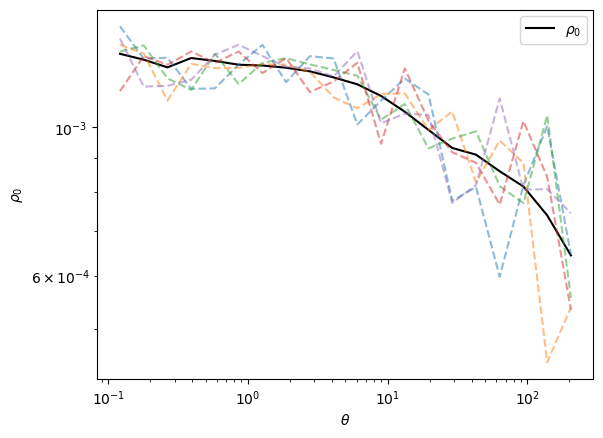

In [8]:
plt.figure()

plt.plot(rho_stats['theta'], rho_stats['rho_0_p'], label=r'$\rho_0$', c='k')
for i in range(5):
    vec = [rho_stats['rho_0_p'][i]+np.random.randn()*np.sqrt(rho_stats['varrho_0_p'][i]) for i in range(len(rho_stats['theta']))]
    plt.plot(rho_stats['theta'], vec, alpha=0.5, ls='--')

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\theta$')
plt.ylabel(r'$\rho_0$')
plt.legend()
plt.show()

In [11]:
tau_vector = build_tau_vec(tau_stats)
rho_matrix = build_rho_matrix_w_noise(rho_stats)
cov_tau = np.load('output_1/rho_tau_stats/cov_tau_SP_v1.4-P3_LFmask.npy')
inv_cov = np.linalg.inv(cov_tau)
inv_cov = (80-60-2)/(80-1)*inv_cov

In [12]:
params = np.linalg.inv(rho_matrix.T @ inv_cov@ rho_matrix) @ rho_matrix.T @ inv_cov @ tau_vector
print(params)

-0.5*(tau_vector - rho_matrix @ params).T @ np.linalg.inv(cov_tau) @ (tau_vector - rho_matrix @ params)

[ 5.39124619e-04  1.00384158e+00 -1.09419877e+00]


-58.06894601273329

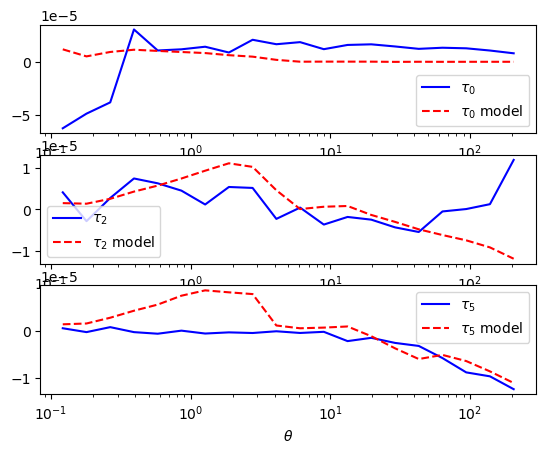

In [13]:
params = [0.0076, 0.6718, 0.1832]

tau_model = rho_matrix @ params
tau_model = tau_model.reshape((20, 3))

plt.figure()

plt.subplot(311)

plt.plot(tau_stats['theta'], tau_stats['tau_0_p'], label=r'$\tau_0$', c='b')
plt.plot(tau_stats['theta'], tau_model[:, 0], label=r'$\tau_0$ model', c='r', ls='--')
plt.xscale('log')
plt.xlabel(r'$\theta$')
plt.legend()

plt.subplot(312)

plt.plot(tau_stats['theta'], tau_stats['theta']*tau_stats['tau_2_p'], label=r'$\tau_2$', c='b')
plt.plot(tau_stats['theta'], tau_stats['theta']*tau_model[:, 1], label=r'$\tau_2$ model', c='r', ls='--')
plt.xscale('log')
plt.xlabel(r'$\theta$')
plt.legend()

plt.subplot(313)

plt.plot(tau_stats['theta'], tau_stats['theta']*tau_stats['tau_5_p'], label=r'$\tau_5$', c='b')
plt.plot(tau_stats['theta'], tau_stats['theta']*tau_model[:, 2], label=r'$\tau_5$ model', c='r', ls='--')
plt.xscale('log')
plt.xlabel(r'$\theta$')
plt.legend()
plt.show()


In [14]:
def compute_xi_sys(rho, alpha, beta, eta):
    return alpha**2*rho['rho_0_p']+beta**2*rho['rho_1_p']+eta**2*rho['rho_3_p']+2*alpha*beta*rho['rho_2_p']+2*beta*eta*rho['rho_4_p']+2*eta*alpha*rho['rho_5_p']


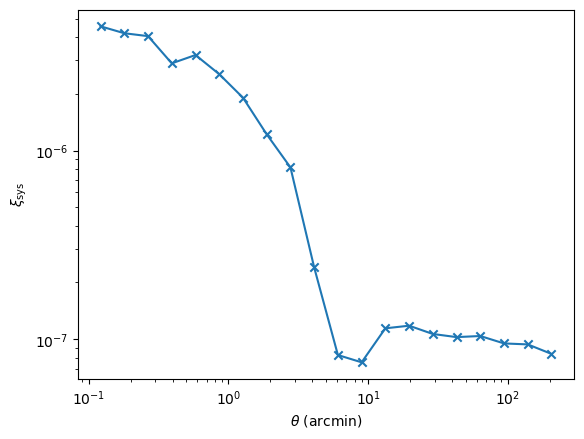

In [15]:
xi_sys = compute_xi_sys(rho_stats, *params)

plt.figure()

plt.plot(rho_stats['theta'], xi_sys, label='Systematic error')
plt.scatter(rho_stats['theta'], xi_sys, marker='x')
plt.yscale('log')
plt.xscale('log')
plt.xlabel(r'$\theta$ (arcmin)')
plt.ylabel(r'$\xi_{\rm sys}$')
plt.show()

In [11]:
catalogs = [
    'SP_v1.4-P3_LFmask',
    'SP_v1.4-P3',
    'SP_v1.3_LFmask_8k',
    'SP_v1.3',
    'SP_axel_v0.0',
    'DES'
]

colors = [
    'black',
    'brown',
    'green',
    'green',
    'cyan',
    'orange'
]

markers = [
    'h',
    'd',
    'p',
    'h',
    '>',
    '*'
]

linestyles = [
    'dashdot',
    'dashed',
    'dotted',
    'solid',
    'dashdot',
    'solid'
]

In [12]:
def plot_xi_sys(catalog, color, marker, linestyle, path):
    plt.figure()
    for cat, col, mark, line in zip(catalogs, colors, markers, linestyles):
        rho_stats = fits.getdata(path + '/rho_stats_' + cat+'.fits')
        tau_stats = fits.getdata(path + '/tau_stats_' + cat+'.fits')
        tau_vector = build_tau_vec(tau_stats)
        rho_matrix = build_rho_matrix_w_noise(rho_stats)
        cov_tau = np.load(path + '/cov_' + cat + '.npy')
        params = np.linalg.inv(rho_matrix.T @ np.linalg.inv(cov_tau) @ rho_matrix) @ rho_matrix.T @ np.linalg.inv(cov_tau) @ tau_vector
        print(cat)
        print(params)
        xi_sys = compute_xi_sys(rho_stats, *params)
        plt.plot(rho_stats['theta'], xi_sys, label=cat, color=col, marker=mark, linestyle=line)
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel(r'$\theta$ (arcmin)')
    plt.ylabel(r'$\xi_{\rm sys}$')
    plt.legend()
    plt.savefig('xi_sys_from_matrix.pdf')
    plt.show()

SP_v1.4-P3_LFmask
[ 0.00981182  0.79891942 -1.90316243]
SP_v1.4-P3
[0.02859368 0.63663603 3.86953154]
SP_v1.3_LFmask_8k
[0.01180518 0.40149868 0.30629783]
SP_v1.3
[ 0.01127253  0.531434   -0.5118189 ]
SP_axel_v0.0
[-0.01583693  0.56655134 -2.02183059]
DES
[ 2.16909722e-03  1.78066611e+00 -2.82468658e+00]


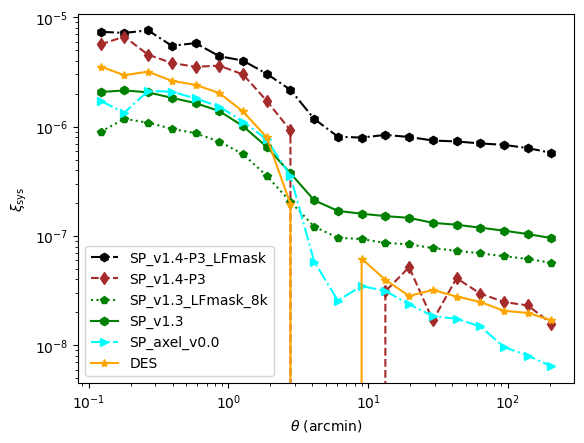

In [13]:
plot_xi_sys(catalogs, colors, markers, linestyles, 'output_jk/rho_tau_stats')

In [14]:
def model(theta, rhos):
        """
        model

        Implements the systematic error. It outputs the tau+ statistics given the rho statistics and a set of parameters theta.

        Parameters
        ----------

        theta : tuple
            Parameters (alpha, beta, eta) of the model.

        Returns
        -------
        np.array
            A flattened array containing the tau+ statistics.
        """
        alpha, beta, eta = theta
        tau_0_p = alpha * rhos["rho_0_p"] + beta * rhos["rho_2_p"] + eta * rhos["rho_5_p"]
        tau_2_p = alpha * rhos["rho_2_p"] + beta * rhos["rho_1_p"] + eta * rhos["rho_4_p"]
        tau_5_p = alpha * rhos["rho_5_p"] + beta * rhos["rho_4_p"] + eta * rhos["rho_3_p"]

        model_output = np.array([
            tau_0_p,
            tau_2_p,
            tau_5_p
        ])

        return model_output.flatten()

In [15]:
theta = [0.0076, 0.6718, 0.1832]
tau_model = model(params, rho_stats)

tau_obs = np.array([tau_stats['tau_0_p'], tau_stats['tau_2_p'], tau_stats['tau_5_p']]).flatten()

In [16]:
-0.5*(tau_model-tau_obs).T@np.linalg.inv(cov_tau)@(tau_model-tau_obs)

-86.37923604571763

## Frequentist approach to estimate the parameters

In [16]:
from shear_psf_leakage.rho_tau_stat import RhoStat, TauStat, PSFErrorFit

In [17]:
sep_units = 'arcmin'
coord_units = 'degrees'
theta_min = 0.1
theta_max = 250
nbins = 20


TreeCorrConfig_xi = {
    'ra_units': coord_units,
    'dec_units': coord_units,
    'min_sep': theta_min,
    'max_sep': theta_max,
    'sep_units': sep_units,
    'nbins': nbins,
    'var_method':'jackknife',
}

In [18]:
rho_stats_handler = RhoStat(
    output='.',
    treecorr_config=TreeCorrConfig_xi,
    verbose=True
)

In [20]:
rho_stats_handler.build_cat_to_compute_rho(
    '/C7home/mkilbing/astro/data/CFIS/v1.0/ShapePipe/P3/unions_shapepipe_psf_2022_P3_v1.4.fits',
    catalog_id='SP_v1.4-P3_LFmask',
    square_size=True,
    mask=True,
    hdu=2
)

Building catalogs...
Catalogs successfully built...
psf_SP_v1.4-P3_LFmask
psf_error_SP_v1.4-P3_LFmask
psf_size_error_SP_v1.4-P3_LFmask


In [21]:
only_p = lambda corrs: np.array([corr.xip for corr in corrs]).flatten()
rho_stats_handler.compute_rho_stats('SP_v1.4-P3_LFmask', 'rho_stats_SP_v1.4-P3_LFmask.fits',
                                    save_cov=True, func=only_p, var_method='jackknife')

Computation of the rho statistics of SP_v1.4-P3_LFmask in progress...
Done...
Computing the covariance...


/home/guerrini/.conda/envs/sp_validation/lib/python3.9/site-packages/treecorr/util.py:665: FutureWarning: Use of keyword-only arguments as positional arguments is deprecated in the function estimate_multi_cov. The following parameters now require an explicit keyword name: ['func']
  warnings.warn(


In [22]:
filenames = ['rho_stats_SP_v1.4-P3_LFmask.fits']
colors=['blue']
versions = ['SP_v1.4-P3_LFmask']

rho_stats_handler.plot_rho_stats(
    filenames,
    colors,
    versions,
    abs=False,
    savefig='rho_stats.png',
    legend='outside'
)

In [23]:
tau_stats_handler = TauStat(
    catalogs=rho_stats_handler.catalogs,
    output='.',
    treecorr_config=TreeCorrConfig_xi,
    verbose=True
)

In [24]:
tau_stats_handler.build_cat_to_compute_tau(
               '/home/mkilbing/astro/data/CFIS/v1.0/ShapePipe/P3/unions_shapepipe_2022_P3_v1.4.fits',
                cat_type='gal',
                catalog_id='SP_v1.4-P3_LFmask',
                square_size=True,
                mask=True,
            )

Building catalog...
Catalogs successfully built...
psf_SP_v1.4-P3_LFmask
psf_error_SP_v1.4-P3_LFmask
psf_size_error_SP_v1.4-P3_LFmask
gal_SP_v1.4-P3_LFmask


In [25]:
only_p = lambda corrs: np.array([corr.xip for corr in corrs]).flatten()
tau_stats_handler.compute_tau_stats(
    'SP_v1.4-P3_LFmask',
    'tau_stats_SP_v1.4-P3_LFmask.fits',
    save_cov=True,
    func=only_p,
    var_method='jackknife',
)

Computation of the tau statistics of SP_v1.4-P3_LFmask in progress...
Done...
Computing the covariance...


In [33]:
psf_fitter = PSFErrorFit(rho_stats_handler, tau_stats_handler, '.')

psf_fitter.load_covariance('cov_tau_SP_v1.4-P3_LFmask.npy', cov_type='tau')
psf_fitter.load_covariance('cov_rho_SP_v1.4-P3_LFmask.npy', cov_type='rho')
params = psf_fitter.get_least_squares_params(npatch=120, apply_debias=True)

Class created. Don't forget to load your rho and tau statistics and define your prior and your likelihood.


In [27]:
samples = psf_fitter.get_least_squares_params_samples(120, True, 10000)

100%|██████████| 10000/10000 [01:13<00:00, 135.26it/s]


In [28]:
params

array([ 7.41736707e-04,  6.30445185e-01, -1.07420541e+00])

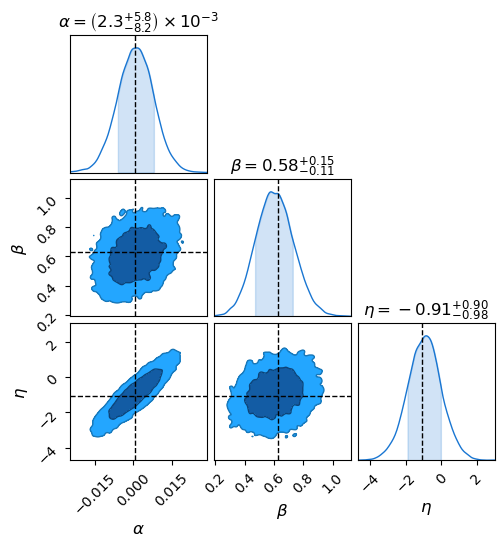

In [29]:
from chainconsumer import ChainConsumer

c = ChainConsumer()
c.add_chain(samples, parameters=[r"$\alpha$", r"$\beta$", r"$\eta$"])
fig = c.plotter.plot(figsize="column", truth=params)
plt.show()

<Figure size 640x480 with 0 Axes>

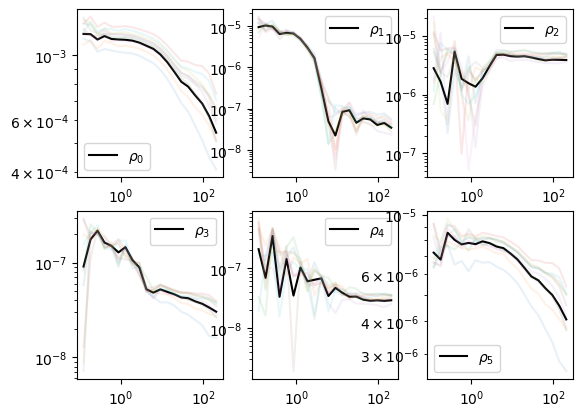

In [155]:
rho_stats = psf_fitter.rho_stat_handler.rho_stats
rho_mean = np.array([rho_stats["rho_0_p"], rho_stats["rho_1_p"], rho_stats["rho_2_p"], rho_stats["rho_3_p"], rho_stats["rho_4_p"], rho_stats["rho_5_p"]])
cov_rho = psf_fitter.cov_rho

plt.figure()

fig, ax = plt.subplots(2, 3)

ax = ax.flatten()

for i in range(6):
    ax[i].plot(rho_stats["theta"], np.abs(rho_mean[i]), label=r'$\rho_{%d}$' % i, c='k')
    ax[i].set_xscale('log')
    ax[i].set_yscale('log')
    ax[i].legend()

for _ in range(10):
    rho = np.random.multivariate_normal(rho_mean.flatten(), cov_rho)
    rho = rho.reshape((6,-1))
    for i in range(6):
        ax[i].plot(rho_stats["theta"], np.abs(rho[i]), alpha=0.1)


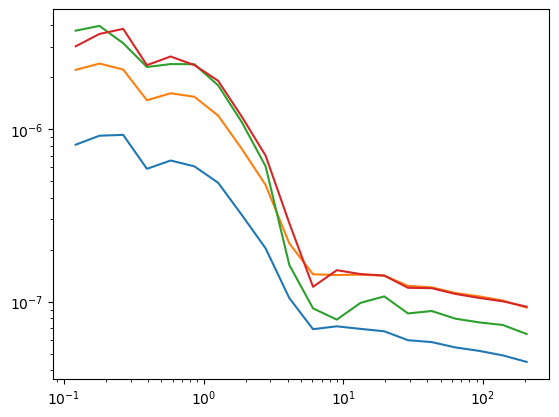

In [31]:
params_try = np.array([
    [0.005, 0.29, -0.26],
    [0.01, 0.47, 0.06],
    [0.015, 0.59, 1.15],
    [0.002, 0.58, -0.91]
])

plt.figure()

rho_stats = psf_fitter.rho_stat_handler.rho_stats
for params in params_try:
    xi_sys = compute_xi_sys(rho_stats, *params)
    plt.plot(rho_stats["theta"], xi_sys)
plt.xscale('log')
plt.yscale('log')
plt.show()

In [36]:
for params in params_try:
    chi_square = psf_fitter.eval_chi_square(params, npatch=120, apply_debias=True)
    print(chi_square)

62.78529940588912
59.72092987734754
60.42417833805023
56.87773560776656


# Sampling several time from the patch distribution.

In [21]:
sep_units = 'arcmin'
coord_units = 'degrees'
theta_min = 0.1
theta_max = 250
nbins = 20


TreeCorrConfig_xi = {
    'ra_units': coord_units,
    'dec_units': coord_units,
    'min_sep': theta_min,
    'max_sep': theta_max,
    'sep_units': sep_units,
    'nbins': nbins,
    'var_method':'jackknife',
}

In [22]:
paths = ['/n17data/sguerrini/multiple_covariance_4/', '/n17data/sguerrini/multiple_covariance_5/', '/n17data/sguerrini/multiple_covariance_6/']
ver = 'SP_v1.4-P3_LFmask'

Class created. Don't forget to load your rho and tau statistics and define your prior and your likelihood.


100%|██████████| 100/100 [00:02<00:00, 33.71it/s]


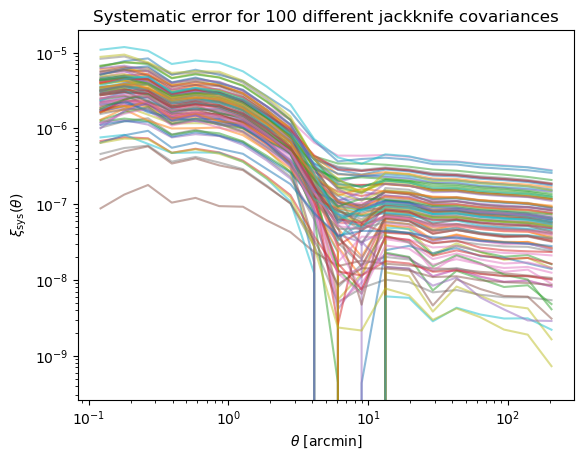

In [23]:
path = '/n17data/sguerrini/multiple_covariance/'

rho_stats_handler = RhoStat(
        output='/n17data/sguerrini/multiple_covariance/',
        treecorr_config=TreeCorrConfig_xi,
        verbose=True
    )
tau_stats_handler = TauStat(
    catalogs=rho_stats_handler.catalogs,
    output='/n17data/sguerrini/multiple_covariance/',
    treecorr_config=TreeCorrConfig_xi,
    verbose=True
    )

psf_fitter = PSFErrorFit(rho_stats_handler, tau_stats_handler, '')
psf_fitter.load_rho_stat(path+'rho_stats_'+ ver + '.fits')
psf_fitter.load_tau_stat(path+'tau_stats_'+ ver + '.fits')

plt.figure()
for i in tqdm(range(100)):
    if os.path.exists(path+'cov_rho_'+ver+'_'+str(i)+'.npy'):
        psf_fitter.load_covariance(path+'cov_tau_'+ver+'_'+str(i)+'.npy', cov_type='tau')
        psf_fitter.load_covariance(path+'cov_rho_'+ver+'_'+str(i)+'.npy', cov_type='rho')
        params = psf_fitter.get_least_squares_params(npatch=120, apply_debias=True)

        xi_sys = psf_fitter.compute_xi_psf_sys(params)
        plt.plot(psf_fitter.rho_stat_handler.rho_stats['theta'], xi_sys, alpha=0.5)
    else:
        break

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\theta$ [arcmin]')
plt.ylabel(r'$\xi_{\rm sys}(\theta)$')
plt.title('Systematic error for 100 different jackknife covariances')
plt.savefig('/n17data/sguerrini/plot_csi/sys_jk_100_cov.png', dpi=600)
plt.show()

Class created. Don't forget to load your rho and tau statistics and define your prior and your likelihood.
68.08479487243783
63.89216726093717
60.688463166712324
58.473682589762824
57.2478255300889
57.01089198769044
57.76288196256754
59.50379545472015
62.23363246414823
65.9523929908519
74.23206377469923
70.57862335025118
67.35137341290313
64.55031396265512
62.17544499950709
60.226766523459084
58.70427853451111
57.607981032663126
56.937874017915156
56.69395749026724
57.071102316890595
57.04129167710745
57.1462565142455
57.38599682830474
57.7605126192852
58.26980388718687
58.91387063200972
59.69271285375377
60.60633055241911
61.654723728005514


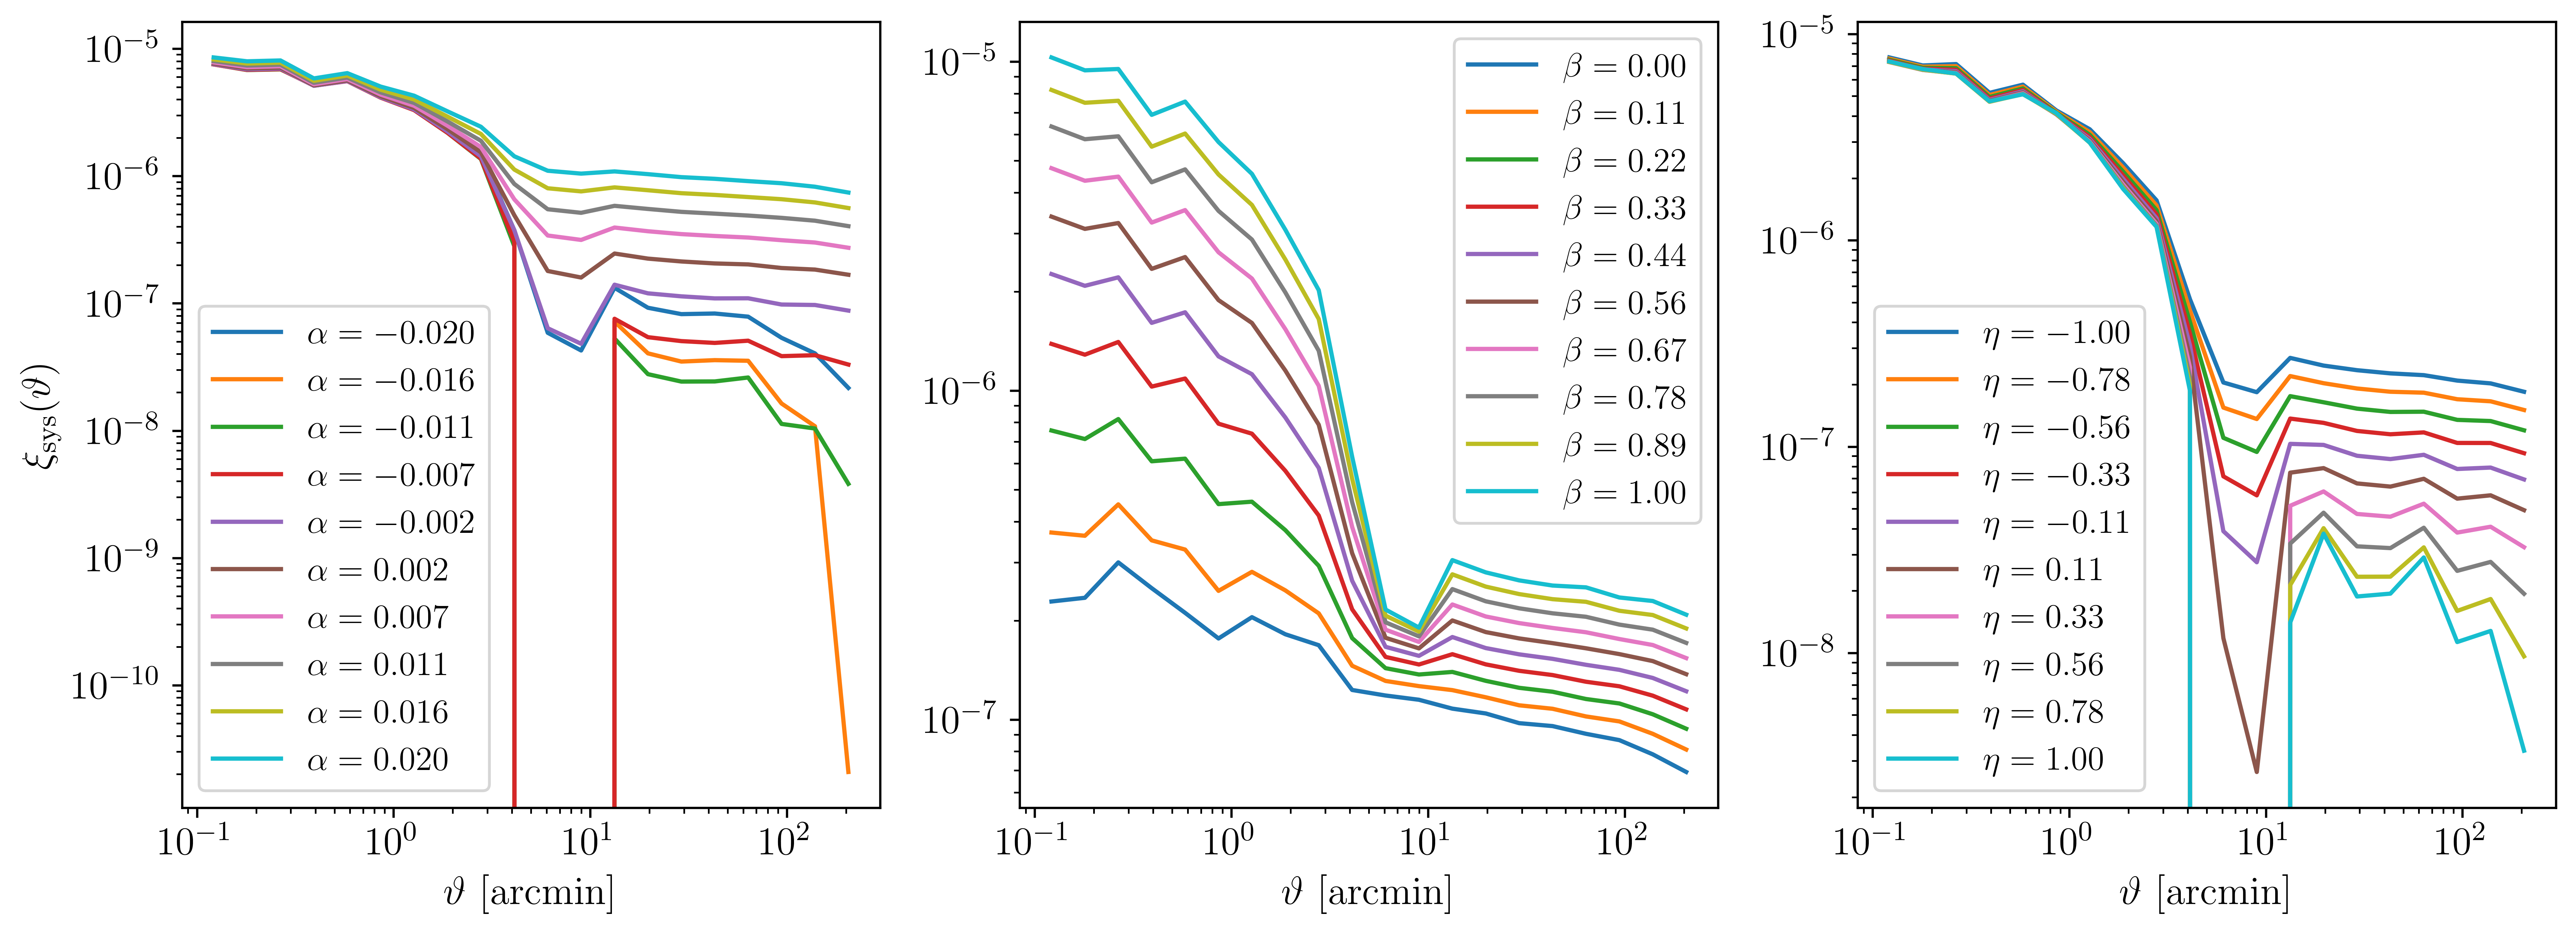

In [28]:
path = '/home/guerrini/sp_validation/notebooks/cosmo_val/output_1/rho_tau_stats/'
ver = 'SP_v1.4-P3_LFmask'

rho_stats_handler = RhoStat(
        output='/n17data/sguerrini/multiple_covariance/',
        treecorr_config=TreeCorrConfig_xi,
        verbose=True
    )
tau_stats_handler = TauStat(
    catalogs=rho_stats_handler.catalogs,
    output='/n17data/sguerrini/multiple_covariance/',
    treecorr_config=TreeCorrConfig_xi,
    verbose=True
    )

psf_fitter = PSFErrorFit(rho_stats_handler, tau_stats_handler, '')
psf_fitter.load_rho_stat(path+'rho_stats_'+ ver + '.fits')
psf_fitter.load_tau_stat(path+'tau_stats_'+ ver + '.fits')
psf_fitter.load_covariance(path+'cov_tau_'+ver+'.npy', cov_type='tau')
psf_fitter.load_covariance(path+'cov_rho_'+ver+'.npy', cov_type='rho')

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Times New Roman"],  # You can change this font if you prefer
    "axes.labelsize": 14,  # Adjust as needed
    "axes.titlesize": 16,  # Adjust as needed
    "xtick.labelsize": 14,  # Adjust as needed
    "ytick.labelsize": 14,  # Adjust as needed
    "legend.fontsize": 12,  # Adjust as needed
    "figure.figsize": (15, 8),  # Adjust as needed
    "figure.dpi": 600  # Adjust as needed
})

eta = np.linspace(-1, 1, 10)
plt.figure(figsize=(15, 5))

plt.subplot(131)

alpha = np.linspace(-0.02, 0.02, 10)

for e in alpha:
    p = [e, 0.86, -1]
    print(psf_fitter.eval_chi_square(p, npatch=120, apply_debias=True))
    xi_sys = psf_fitter.compute_xi_psf_sys(p)
    plt.plot(psf_fitter.rho_stat_handler.rho_stats['theta'], xi_sys, label=rf"$\alpha={e:.3f}$")
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\vartheta$ [arcmin]')
plt.ylabel(r'$\xi_{\rm sys}(\vartheta)$')
plt.legend()

plt.subplot(132)

beta = np.linspace(0, 1, 10)
for e in beta:
    p = [0.003, e, -1]
    print(psf_fitter.eval_chi_square(p, npatch=120, apply_debias=True))
    xi_sys = psf_fitter.compute_xi_psf_sys(p)
    plt.plot(psf_fitter.rho_stat_handler.rho_stats['theta'], xi_sys, label=rf"$\beta={e:.2f}$")
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\vartheta$ [arcmin]')
plt.legend()

plt.subplot(133)
for e in eta:
    p = [0.003, 0.86, e]
    print(psf_fitter.eval_chi_square(p, npatch=120, apply_debias=True))
    xi_sys = psf_fitter.compute_xi_psf_sys(p)
    plt.plot(psf_fitter.rho_stat_handler.rho_stats['theta'], xi_sys, label=rf"$\eta={e:.2f}$")
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\vartheta$ [arcmin]')
plt.legend()
plt.savefig('xi_sys_dependency.png', dpi=600)
plt.show()

Class created. Don't forget to load your rho and tau statistics and define your prior and your likelihood.
74.09786857728014
70.29406901124881
66.97128843058897
64.1295268353007
61.768784225383996
59.88906060083879
58.490355961665145
57.57267030786303
57.13600363943242
57.180355956373404


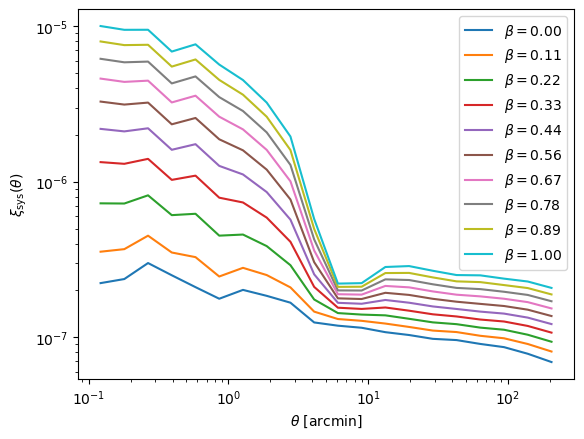

In [14]:
path = '/home/guerrini/sp_validation/notebooks/cosmo_val/output/rho_tau_stats/'
ver = 'SP_v1.4-P3_LFmask'

rho_stats_handler = RhoStat(
        output='/n17data/sguerrini/multiple_covariance/',
        treecorr_config=TreeCorrConfig_xi,
        verbose=True
    )
tau_stats_handler = TauStat(
    catalogs=rho_stats_handler.catalogs,
    output='/n17data/sguerrini/multiple_covariance/',
    treecorr_config=TreeCorrConfig_xi,
    verbose=True
    )

psf_fitter = PSFErrorFit(rho_stats_handler, tau_stats_handler, '')
psf_fitter.load_rho_stat(path+'rho_stats_'+ ver + '.fits')
psf_fitter.load_tau_stat(path+'tau_stats_'+ ver + '.fits')
psf_fitter.load_covariance(path+'cov_tau_'+ver+'.npy', cov_type='tau')
psf_fitter.load_covariance(path+'cov_rho_'+ver+'.npy', cov_type='rho')

beta = np.linspace(0, 1, 10)
plt.figure()
for e in beta:
    p = [0.003, e, -1]
    print(psf_fitter.eval_chi_square(p, npatch=120, apply_debias=True))
    xi_sys = psf_fitter.compute_xi_psf_sys(p)
    plt.plot(psf_fitter.rho_stat_handler.rho_stats['theta'], xi_sys, label=rf"$\beta={e:.2f}$")
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\theta$ [arcmin]')
plt.ylabel(r'$\xi_{\rm sys}(\theta)$')
plt.legend()
plt.savefig('vary_beta.png', dpi=600)
plt.show()

Class created. Don't forget to load your rho and tau statistics and define your prior and your likelihood.
77.97672516698209
71.0435096017171
65.50862695485588
61.3720772263989
58.633860416345854
57.29397652469681
57.352425551451795
58.80920749661075
61.66432236017366
65.91777014214074


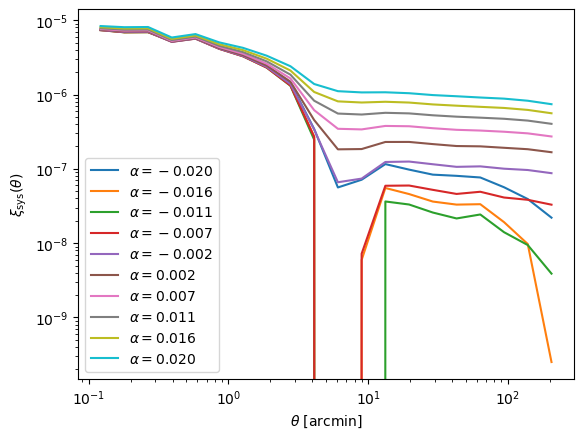

In [15]:
path = '/home/guerrini/sp_validation/notebooks/cosmo_val/output/rho_tau_stats/'
ver = 'SP_v1.4-P3_LFmask'

rho_stats_handler = RhoStat(
        output='/n17data/sguerrini/multiple_covariance/',
        treecorr_config=TreeCorrConfig_xi,
        verbose=True
    )
tau_stats_handler = TauStat(
    catalogs=rho_stats_handler.catalogs,
    output='/n17data/sguerrini/multiple_covariance/',
    treecorr_config=TreeCorrConfig_xi,
    verbose=True
    )

psf_fitter = PSFErrorFit(rho_stats_handler, tau_stats_handler, '')
psf_fitter.load_rho_stat(path+'rho_stats_'+ ver + '.fits')
psf_fitter.load_tau_stat(path+'tau_stats_'+ ver + '.fits')
psf_fitter.load_covariance(path+'cov_tau_'+ver+'.npy', cov_type='tau')
psf_fitter.load_covariance(path+'cov_rho_'+ver+'.npy', cov_type='rho')

alpha = np.linspace(-0.02, 0.02, 10)
plt.figure()
for e in alpha:
    p = [e, 0.86, -1]
    print(psf_fitter.eval_chi_square(p, npatch=120, apply_debias=True))
    xi_sys = psf_fitter.compute_xi_psf_sys(p)
    plt.plot(psf_fitter.rho_stat_handler.rho_stats['theta'], xi_sys, label=rf"$\alpha={e:.3f}$")
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\theta$ [arcmin]')
plt.ylabel(r'$\xi_{\rm sys}(\theta)$')
plt.legend()
plt.savefig('vary_alpha.png', dpi=600)
plt.show()

In [84]:
#Average covariance matrices 
for path in paths:
    cov = np.zeros((60, 60))
    i=0
    while os.path.exists(path+'cov_tau_'+ver+'_'+str(i)+'.npy') and i<60:
        cov_loc = np.load(path+'cov_tau_'+ver+'_'+str(i)+'.npy')
        cov += cov_loc
        i+=1
    cov = cov/i
    print(i)
    np.save( path+'mean_cov.npy', cov)
    

60
60
60


[ 0.00325274  0.61347806 -0.25545921]
[ 0.00340336  0.58934788 -0.3040947 ]
[ 0.00428065  0.58473157 -0.20346014]
[0.00762496 0.62112627 0.310535  ]


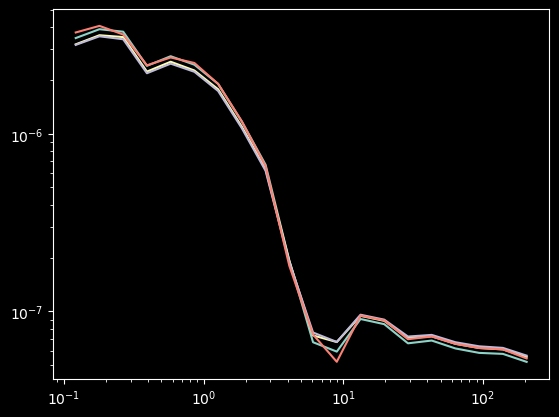

In [85]:
plt.figure()

for path in paths:
    psf_fitter.load_covariance(path+'mean_cov.npy', cov_type='tau')
    psf_fitter.load_covariance(path+'cov_rho_'+ver+'_1.npy', cov_type='rho')
    params = psf_fitter.get_least_squares_params(npatch=120, apply_debias=True)
    print(params)
    xi_sys = psf_fitter.compute_xi_psf_sys(params)
    plt.plot(psf_fitter.rho_stat_handler.rho_stats['theta'], xi_sys)
path_tau = '/home/guerrini/sp_validation/notebooks/cosmo_val/output/rho_tau_stats/cov_tau_SP_v1.4-P3.npy'
path_rho = '/home/guerrini/sp_validation/notebooks/cosmo_val/output/rho_tau_stats/cov_rho_SP_v1.4-P3.npy'
psf_fitter.load_covariance(path_tau, cov_type='tau')
psf_fitter.load_covariance(path_rho, cov_type='rho')
params = psf_fitter.get_least_squares_params(npatch=200, apply_debias=True)
print(params)
xi_sys = psf_fitter.compute_xi_psf_sys(params)
plt.plot(psf_fitter.rho_stat_handler.rho_stats['theta'], xi_sys)
plt.xscale('log')
plt.yscale('log')
plt.show()

100%|██████████| 10000/10000 [01:22<00:00, 120.59it/s]


Number of samples: 10000

Parameters constraints
----------------------
Parameter: $\alpha$=0.0046^+0.0076_0.0076
Parameter: $\beta$=0.5702^+0.1416_0.1467
Parameter: $\eta$=-0.0120^+1.0255_1.0016
Chi square: 46.26949259956513


100%|██████████| 10000/10000 [01:23<00:00, 119.79it/s]


Number of samples: 10000

Parameters constraints
----------------------
Parameter: $\alpha$=0.0051^+0.0076_0.0077
Parameter: $\beta$=0.5551^+0.1408_0.1424
Parameter: $\eta$=0.0312^+1.0199_1.0107
Chi square: 45.90367026685731


100%|██████████| 10000/10000 [01:21<00:00, 122.17it/s]


Number of samples: 10000

Parameters constraints
----------------------
Parameter: $\alpha$=0.0049^+0.0076_0.0075
Parameter: $\beta$=0.5626^+0.1432_0.1422
Parameter: $\eta$=-0.0704^+0.9845_1.0099
Chi square: 47.03938664471496


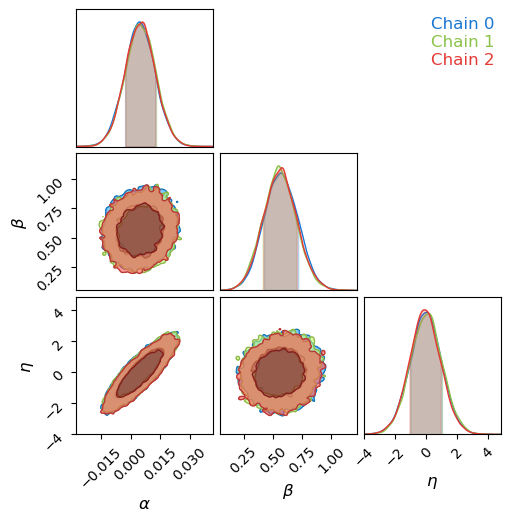

In [23]:
from chainconsumer import ChainConsumer

c = ChainConsumer()

for path in paths:
    psf_fitter.load_covariance(path+'mean_cov.npy', cov_type='tau')
    samples, _, _ = psf_fitter.get_least_squares_params_samples(120, True, 10000)
    np.save(path+'samples_params.npy', samples)
    c.add_chain(samples, parameters=[r"$\alpha$", r"$\beta$", r"$\eta$"])
fig = c.plotter.plot(figsize='column')
plt.show()

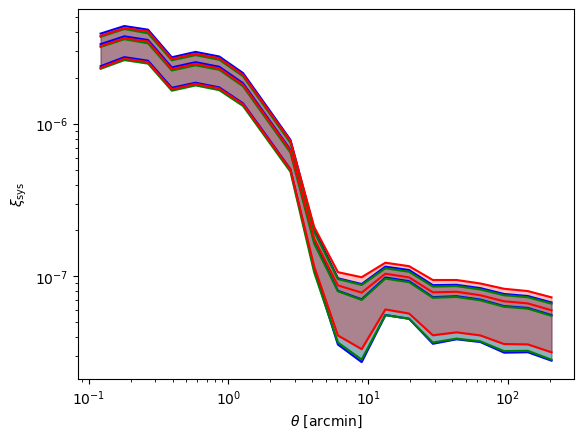

In [36]:
colors = ['blue', 'green', 'red']

plt.figure()

for path, color in zip(paths, colors):
    psf_fitter.load_covariance(path+'mean_cov.npy', cov_type='tau')
    samples = np.load(path + 'samples_params.npy')
    quant = 0.683
    quantiles = [1-quant, quant]
    nbins = psf_fitter.rho_stat_handler._treecorr_config['nbins']
    xi_psf_sys_samples = np.array([]).reshape(0, nbins)

    for i in range(len(samples)):
        xi_psf_sys = psf_fitter.compute_xi_psf_sys(samples[i])
        xi_psf_sys_samples = np.vstack([xi_psf_sys_samples, xi_psf_sys])

    xi_psf_sys_mean = np.mean(xi_psf_sys_samples, axis=0)
    xi_psf_sys_quant = np.quantile(xi_psf_sys_samples, quantiles, axis=0)
    theta = psf_fitter.rho_stat_handler.rho_stats['theta']
    plt.plot(theta, xi_psf_sys_mean, color=color)
    plt.plot(theta, xi_psf_sys_quant[0], color=color)
    plt.plot(theta, xi_psf_sys_quant[1], color=color)
    plt.fill_between(theta, xi_psf_sys_quant[0], xi_psf_sys_quant[1], color=color, alpha=0.25)

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r"$\theta$ [arcmin]")
plt.ylabel(r"$\xi_{\rm sys}$")
plt.show()

In [17]:
#plot CSI

out_dir = '/home/guerrini/sp_validation/notebooks/cosmo_val/output/rho_tau_stats/'

rho_stat_handler = RhoStat(
        output=out_dir,
        treecorr_config=TreeCorrConfig_xi,
        verbose=False)

versions = ['SP_v1.3_LFmask_8k', 'SP_v1.4-P3', 'SP_v1.4-P3_LFmask',  'SP_axel_v0.0', 'DES']
colors = ['green', 'brown', 'white', 'cyan', 'orange']

filenames = []
for ver in versions:
    filenames.append(f"rho_stats_{ver}.fits")

rho_stat_handler.plot_rho_stats(
    filenames,
    colors,
    versions,
    abs=False,
    savefig='rho_stats_csi.png',
    legend='outside'
)

(<Figure size 1500x600 with 3 Axes>,
 array([[<Axes: xlabel='$\\theta$ [arcmin]', ylabel='$\\tau_0(\\theta)$'>,
         <Axes: xlabel='$\\theta$ [arcmin]', ylabel='$\\tau_1(\\theta)$'>,
         <Axes: xlabel='$\\theta$ [arcmin]', ylabel='$\\tau_2(\\theta)$'>]],
       dtype=object))

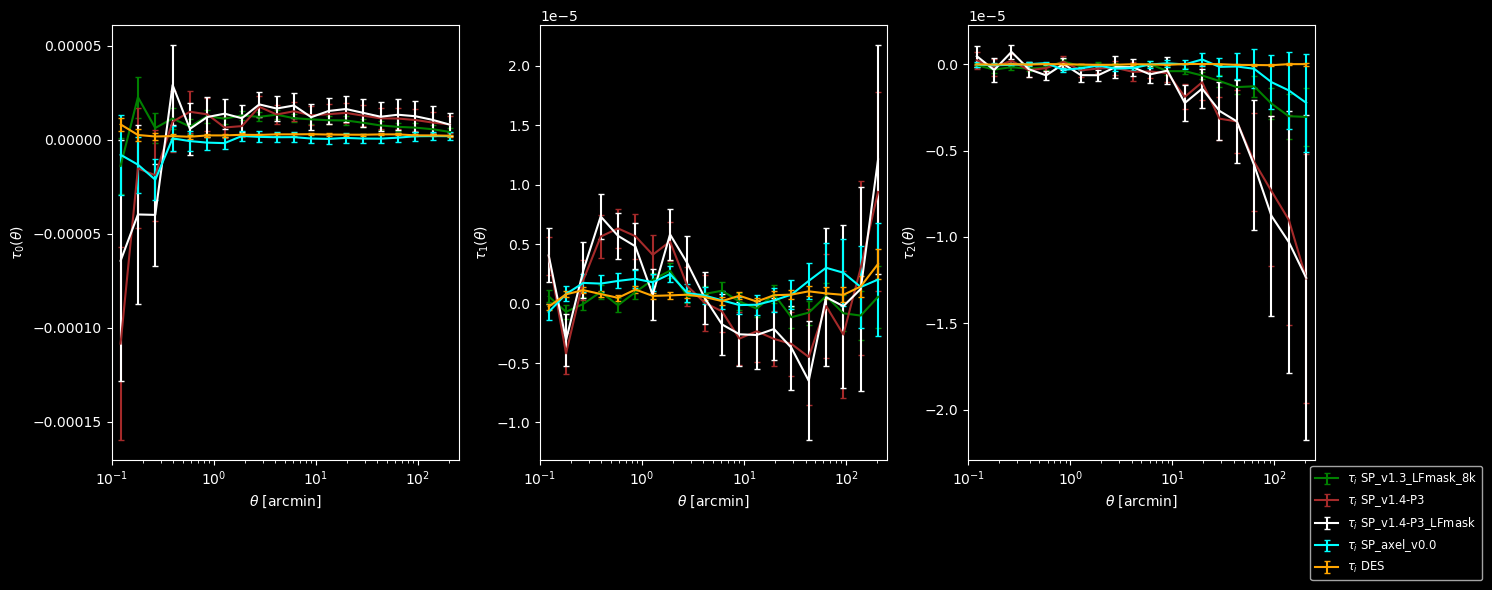

In [19]:
tau_stat_handler = TauStat(
        catalogs=rho_stat_handler.catalogs,
        output=out_dir,
        treecorr_config=TreeCorrConfig_xi,
        verbose=True,
    )

filenames = []
for ver in versions:
    filenames.append(f"tau_stats_{ver}.fits")

tau_stat_handler.plot_tau_stats(
    filenames,
    colors,
    versions,
    savefig='tau_stats_csi.png',
    plot_tau_m=False,
    legend="outside"
)

In [23]:
filenames = []
for ver in versions:
    filenames.append(f"/home/guerrini/sp_validation/notebooks/cosmo_val/output/xi_pm_{ver}.txt")

plt.figure()
for filename in filenames:
    xi_plus = np.load(filename, allow_pickle=True)
    print(xi_plus)
    plt.plot(xi_plus['theta'], xi_plus['xip'], label=filename.split('/')[-1])
plt.show()

UnpicklingError: Failed to interpret file '/home/guerrini/sp_validation/notebooks/cosmo_val/output/xi_pm_SP_v1.3_LFmask_8k.txt' as a pickle

<Figure size 640x480 with 0 Axes>

# Parameters estimate using tau and rho minus

In [86]:
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

from shear_psf_leakage.rho_tau_stat import RhoStat, TauStat, PSFErrorFit

In [87]:
def build_tau_vec(data):
    tau_obs = np.array([data['tau_0_p'], data['tau_2_p'], data['tau_5_p'],
                        data['tau_0_m'], data['tau_2_m'], data['tau_5_m']]).flatten()
    return tau_obs

def build_rho_matrix(data):
    n_thetas = len(data['theta'])
    rho_matrix = np.zeros((6*n_thetas, 3))
    for i in range(n_thetas):
        rho_matrix[i] = [data['rho_0_p'][i], data['rho_2_p'][i], data['rho_5_p'][i]]
        rho_matrix[i+n_thetas] = [data['rho_2_p'][i], data['rho_1_p'][i], data['rho_4_p'][i]]
        rho_matrix[i+2*n_thetas] = [data['rho_5_p'][i], data['rho_4_p'][i], data['rho_3_p'][i]]
        rho_matrix[i+3*n_thetas] = [data['rho_0_m'][i], data['rho_2_m'][i], data['rho_5_m'][i]]
        rho_matrix[i+4*n_thetas] = [data['rho_2_m'][i], data['rho_1_m'][i], data['rho_4_m'][i]]
        rho_matrix[i+5*n_thetas] = [data['rho_5_m'][i], data['rho_4_m'][i], data['rho_3_m'][i]]
    return rho_matrix

In [88]:
def get_lsq_params(rho_matrix, tau_vector, cov_tau):
    inv_cov = np.linalg.inv(cov_tau)
    inv_cov = (120-120-2)/(120-1)*inv_cov
    params = np.linalg.inv(rho_matrix.T @ inv_cov@ rho_matrix) @ rho_matrix.T @ inv_cov @ tau_vector
    return params

In [119]:
rho_stats = fits.getdata('/n17data/sguerrini/multiple_covariance_LF/rho_stats_SP_v1.4-P3_LFmask.fits')
tau_stats = fits.getdata('/n17data/sguerrini/multiple_covariance_LF/tau_stats_SP_v1.4-P3_LFmask.fits')

tau_vector = build_tau_vec(tau_stats)
rho_matrix = build_rho_matrix(rho_stats)

paths = ['/n17data/sguerrini/multiple_covariance_LF/', '/n17data/sguerrini/multiple_covariance_LF_2/', '/n17data/sguerrini/multiple_covariance_LF_3/']
version = 'SP_v1.4-P3_LFmask'

for path in paths:
    cov_t = np.zeros((120, 120))
    cov_r = np.zeros((240, 240))
    i=0
    while i<100 and os.path.exists(path+'cov_tau_'+version+'_'+str(i)+'.npy') and os.path.exists(path+'cov_rho_'+version+'_'+str(i)+'.npy'):
        cov_tau = np.load(path+'cov_tau_'+version+'_'+str(i)+'.npy')
        cov_rho = np.load(path+'cov_rho_'+version+'_'+str(i)+'.npy')
        cov_t += cov_tau
        cov_r += cov_rho
        i+=1

    print(i)
    np.save(path+'mean_cov_tau.npy', cov_t/i)
    np.save(path+'mean_cov_rho.npy', cov_r/i)

100
0
0


/tmp/ipykernel_15910/3754388666.py:22: RuntimeWarning: invalid value encountered in divide
  np.save(path+'mean_cov_tau.npy', cov_t/i)
/tmp/ipykernel_15910/3754388666.py:23: RuntimeWarning: invalid value encountered in divide
  np.save(path+'mean_cov_rho.npy', cov_r/i)


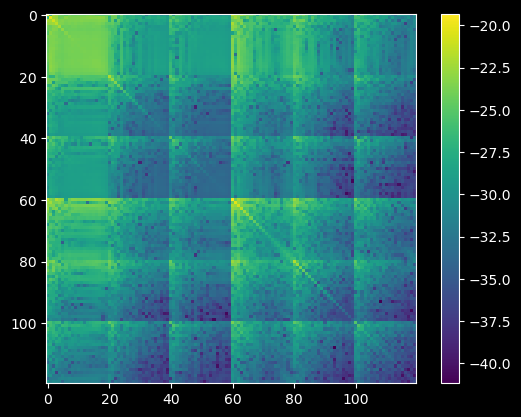

In [114]:
cov_tau = np.load(path+'mean_cov_tau.npy')

plt.figure()

plt.imshow(np.log(np.abs(cov_tau)))
plt.colorbar()
plt.show()

[0.01517501 0.97491371 0.64643124]


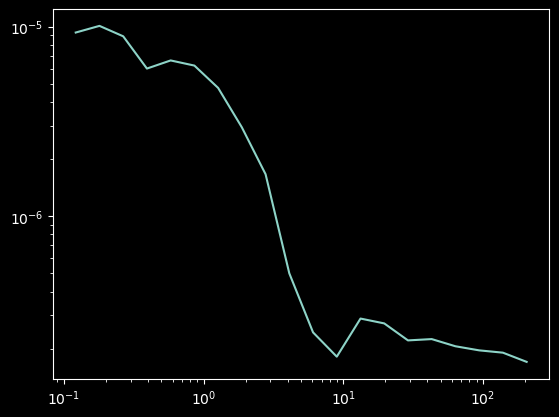

In [115]:
params = get_lsq_params(rho_matrix, tau_vector, cov_tau)
print(params)
xi_psf = psf_fitter.compute_xi_psf_sys(params)

plt.figure()

plt.plot(rho_stats['theta'], xi_psf)
plt.xscale('log')
plt.yscale('log')
plt.show()

In [27]:
np.save(path+'trunc_cov_tau.npy', cov_tau[:60, :60])

In [29]:
sep_units = 'arcmin'
coord_units = 'degrees'
theta_min = 0.1
theta_max = 250
nbins = 20


TreeCorrConfig_xi = {
    'ra_units': coord_units,
    'dec_units': coord_units,
    'min_sep': theta_min,
    'max_sep': theta_max,
    'sep_units': sep_units,
    'nbins': nbins,
    'var_method':'jackknife',
}

rho_stats_handler = RhoStat(
        output='/n17data/sguerrini/multiple_covariance_LF/',
        treecorr_config=TreeCorrConfig_xi,
        verbose=True
    )

tau_stats_handler = TauStat(
    catalogs=rho_stats_handler.catalogs,
    output='/n17data/sguerrini/multiple_covariance_LF/',
    treecorr_config=TreeCorrConfig_xi,
    verbose=True
    )

psf_fitter = PSFErrorFit(rho_stats_handler, tau_stats_handler, '')
psf_fitter.load_covariance(path+'trunc_cov_tau.npy', cov_type='tau')
psf_fitter.load_rho_stat(path+'rho_stats_'+ version + '.fits')
psf_fitter.load_tau_stat(path+'tau_stats_'+ version + '.fits')

params = psf_fitter.get_least_squares_params(npatch=120, apply_debias=True)
params

Class created. Don't forget to load your rho and tau statistics and define your prior and your likelihood.


array([ 0.00182108,  1.01440411, -0.8383745 ])